# Policy-Shock Hold-the-Dip Test

This notebook extends the AQR "Hold the Dip" project into a small event study.

Instead of waiting for a rolling drawdown signal, I use a simpler event-triggered version of the idea: if a policy shock happens, buy SPY on the event's market date and hold it for a few fixed periods.

This is intentionally separate from the main strategy notebooks. The goal is to ask whether policy-driven selloffs were worth holding through, using a clean event calendar and simple forward-return tests.

## Imports

In [36]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



## Event Calendar

These are policy changes or remarks that are specific enough to timestamp and plausibly connected to a market dip or rebound.

`event_date` is when the policy action or remark happened. `market_date` is the trading day I actually use for the test. If something happened over the weekend or after the close, I anchor on the next trading day.

In [37]:
#this was collected from my recollection of what happened, 
    #news searches, and AI recommendations.

events = pd.DataFrame([
    {
        "event_date": "2025-02-01",
        "market_date": "2025-02-03",
        "event_name": "Canada, Mexico, and China tariff orders",
        "event_type": "tariff escalation",
        "description": "Trump signed orders imposing tariffs on Canada, Mexico, and China. The event happened over the weekend, so I anchor on the next trading day.",
        "source": "https://www.washingtonpost.com/business/2025/02/01/tariff-mexico-canada-trump/",
    },
    {
        "event_date": "2025-03-03",
        "market_date": "2025-03-03",
        "event_name": "Tariffs on Canada and Mexico confirmed",
        "event_type": "tariff escalation",
        "description": "Trump confirmed that tariffs on Canada and Mexico would proceed, with China tariffs also rising. Markets sold off on tariff-growth concerns.",
        "source": "https://www.businessinsider.com/trump-mexico-canada-tariffs-latest-2025-3",
    },
    {
        "event_date": "2025-03-09",
        "market_date": "2025-03-10",
        "event_name": "Recession concern / transition remark",
        "event_type": "macro remark",
        "description": "Trump declined to rule out recession risk and described a transition period. The next trading day saw a broad selloff.",
        "source": "https://apnews.com/article/174603e75feb9d5cca96c08817e0c7c2",
    },
    {
        "event_date": "2025-03-13",
        "market_date": "2025-03-13",
        "event_name": "EU tariff threat / correction territory",
        "event_type": "tariff escalation",
        "description": "A new tariff threat against European goods added to trade-war uncertainty as the S&P 500 moved into correction territory.",
        "source": "https://apnews.com/article/1c8e59d6f2661c6e3c6aeda8ab07a583",
    },
    {
        "event_date": "2025-04-02",
        "market_date": "2025-04-03",
        "event_name": "Liberation Day reciprocal tariffs",
        "event_type": "tariff escalation",
        "description": "Trump announced broad reciprocal tariffs after the close. I anchor on the next trading day because that is when the cash market absorbed the news.",
        "source": "https://en.wikipedia.org/wiki/Liberation_Day_tariffs",
    },
    {
        "event_date": "2025-04-04",
        "market_date": "2025-04-04",
        "event_name": "China retaliates against tariff package",
        "event_type": "retaliation",
        "description": "China announced retaliatory tariffs, deepening the selloff and turning the event into a larger trade-war shock.",
        "source": "https://apnews.com/article/d86db525c370e9da834e6dfb76e23b86",
    },
    {
        "event_date": "2025-04-09",
        "market_date": "2025-04-09",
        "event_name": "90-day reciprocal tariff pause",
        "event_type": "tariff walkback",
        "description": "Trump announced a 90-day tariff pause for most countries except China. This is a reversal event rather than a dip event, but it is central to testing whether holding the prior dip worked.",
        "source": "https://apnews.com/article/721a3a5971f1b254981d32f4acb9eb17",
    },
    {
        "event_date": "2026-07-08",
        "market_date": "2026-07-08",
        "event_name": "Iran ceasefire is over remark",
        "event_type": "geopolitical remark",
        "description": "Trump said the Iran ceasefire was over. Oil jumped and global equities sold off, making this a recent policy-driven volatility event.",
        "source": "https://apnews.com/article/671d9c94b302f7db533f46baa18387d3",
    },
])

events["event_date"] = pd.to_datetime(events["event_date"]) #to_datetime!!
events["market_date"] = pd.to_datetime(events["market_date"])

events

,event_date,market_date,event_name,event_type,description,source
0,2025-02-01,2025-02-03,"Canada, Mexico, and China tariff orders",tariff escalation,Trump signed orders imposing tariffs on Canada...,https://www.washingtonpost.com/business/2025/0...
1,2025-03-03,2025-03-03,Tariffs on Canada and Mexico confirmed,tariff escalation,Trump confirmed that tariffs on Canada and Mex...,https://www.businessinsider.com/trump-mexico-c...
2,2025-03-09,2025-03-10,Recession concern / transition remark,macro remark,Trump declined to rule out recession risk and ...,https://apnews.com/article/174603e75feb9d5cca9...
3,2025-03-13,2025-03-13,EU tariff threat / correction territory,tariff escalation,A new tariff threat against European goods add...,https://apnews.com/article/1c8e59d6f2661c6e3c6...
4,2025-04-02,2025-04-03,Liberation Day reciprocal tariffs,tariff escalation,Trump announced broad reciprocal tariffs after...,https://en.wikipedia.org/wiki/Liberation_Day_t...
5,2025-04-04,2025-04-04,China retaliates against tariff package,retaliation,"China announced retaliatory tariffs, deepening...",https://apnews.com/article/d86db525c370e9da834...
6,2025-04-09,2025-04-09,90-day reciprocal tariff pause,tariff walkback,Trump announced a 90-day tariff pause for most...,https://apnews.com/article/721a3a5971f1b254981...
7,2026-07-08,2026-07-08,Iran ceasefire is over remark,geopolitical remark,Trump said the Iran ceasefire was over. Oil ju...,https://apnews.com/article/671d9c94b302f7db533...


## Pull SPY Data

I only need enough SPY data to cover the earliest event, the latest event, and the longest holding period. Since holding periods are measured in trading days, I add extra calendar-day buffer around the download range.

In [38]:
hold_periods = [5, 10, 20, 30, 60]
max_hold_days = max(hold_periods)
buffer_days = 20

start_date = events["market_date"].min() - pd.Timedelta(days=buffer_days)
end_date = events["market_date"].max() + pd.Timedelta(days=max_hold_days * 2)

spy = yf.download(
    "SPY",
    start=start_date.strftime("%Y-%m-%d"),
    end=end_date.strftime("%Y-%m-%d"),
    auto_adjust=True,
    progress=False,
)

spy_prices = spy["Close"].squeeze()

spy_prices.tail()

Date
2026-07-13    749.169983
2026-07-14    751.830017
2026-07-15    754.809998
2026-07-16    750.719971
2026-07-17    743.289978
Name: SPY, dtype: float64

## Event-Triggered Holding Returns

This is the simple version of "hold the dip" for policy events:

1. Find the first tradable SPY date on or after the event's `market_date`.
2. Buy SPY at that close.
3. Sell after 5, 10, 20, 30, and 60 trading days.
4. Compare the forward returns across events and event types.

This does not use a drawdown trigger. The event itself is the trigger.

In [39]:
rows = []

for _, event in events.iterrows(): #for each event
    future_prices = spy_prices.loc[event["market_date"]:] # 

    if len(future_prices) == 0:
        continue

    buy_date = future_prices.index[0] #first date in future prices ("market_date")
    buy_price = future_prices.iloc[0] #future prices stores (date, price)

    row = {
        "event_name": event["event_name"],
        "event_type": event["event_type"],
        "event_date": event["event_date"],
        "market_date": event["market_date"],
        "buy_date": buy_date,
        "buy_price": buy_price,
    }

    for hold in hold_periods:
        if hold < len(future_prices):
            sell_date = future_prices.index[hold]
            sell_price = future_prices.iloc[hold]
            row[f"{hold}d_sell_date"] = sell_date
            row[f"{hold}d_return"] = sell_price / buy_price - 1
        else:
            row[f"{hold}d_sell_date"] = pd.NaT
            row[f"{hold}d_return"] = np.nan

    rows.append(row)

event_hold_returns = pd.DataFrame(rows)

event_hold_returns

,event_name,event_type,event_date,market_date,buy_date,buy_price,5d_sell_date,5d_return,10d_sell_date,10d_return,20d_sell_date,20d_return,30d_sell_date,30d_return,60d_sell_date,60d_return
0,"Canada, Mexico, and China tariff orders",tariff escalation,2025-02-01,2025-02-03,2025-02-03,587.708557,2025-02-10,0.011844,2025-02-18,0.022952,2025-03-04,-0.034980,2025-03-18,-0.061479,2025-04-30,-0.069528
1,Tariffs on Canada and Mexico confirmed,tariff escalation,2025-03-03,2025-03-03,2025-03-03,573.944153,2025-03-10,-0.039724,2025-03-17,-0.028470,2025-03-31,-0.038880,2025-04-14,-0.073707,2025-05-28,0.009812
2,Recession concern / transition remark,macro remark,2025-03-09,2025-03-10,2025-03-10,551.144531,2025-03-17,0.011720,2025-03-24,0.027163,2025-04-07,-0.097547,2025-04-22,-0.056627,2025-06-04,0.066257
3,EU tariff threat / correction territory,tariff escalation,2025-03-13,2025-03-13,2025-03-13,542.138611,2025-03-20,0.025516,2025-03-27,0.031493,2025-04-10,-0.045812,2025-04-25,0.001590,2025-06-09,0.090791
4,Liberation Day reciprocal tariffs,tariff escalation,2025-04-02,2025-04-03,2025-04-03,529.253845,2025-04-10,-0.022583,2025-04-17,-0.019173,2025-05-02,0.056009,2025-05-16,0.107136,2025-07-01,0.154231
5,China retaliates against tariff package,retaliation,2025-04-04,2025-04-04,2025-04-04,498.269684,2025-04-11,0.056721,2025-04-21,0.017020,2025-05-05,0.115243,2025-05-19,0.177268,2025-07-02,0.231563
6,90-day reciprocal tariff pause,tariff walkback,2025-04-09,2025-04-09,2025-04-09,541.008423,2025-04-16,-0.041851,2025-04-24,-0.003518,2025-05-08,0.029966,2025-05-22,0.062830,2025-07-08,0.134071
7,Iran ceasefire is over remark,geopolitical remark,2026-07-08,2026-07-08,2026-07-08,745.400024,2026-07-15,0.012624,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN


## Average Returns by Event Type

This groups the event-triggered returns by type. It is a first pass at the actual research question: did tariff escalations, tariff walkbacks, macro remarks, or geopolitical remarks behave differently after the initial shock?

In [40]:
return_cols = [f"{hold}d_return" for hold in hold_periods] 

#recall: you can do ["5d_return, 10d_return, ..."] and it still indexes as a df

event_type_summary = event_hold_returns.groupby("event_type")[return_cols].mean()

event_type_summary

,5d_return,10d_return,20d_return,30d_return,60d_return
event_type,,,,,
geopolitical remark,0.012624,NaN,NaN,NaN,NaN
macro remark,0.011720,0.027163,-0.097547,-0.056627,0.066257
retaliation,0.056721,0.017020,0.115243,0.177268,0.231563
tariff escalation,-0.006237,0.001701,-0.015916,-0.006615,0.046327
tariff walkback,-0.041851,-0.003518,0.029966,0.062830,0.134071


## Simple Plot

This plot shows the average event-triggered SPY return by holding period for each event type.

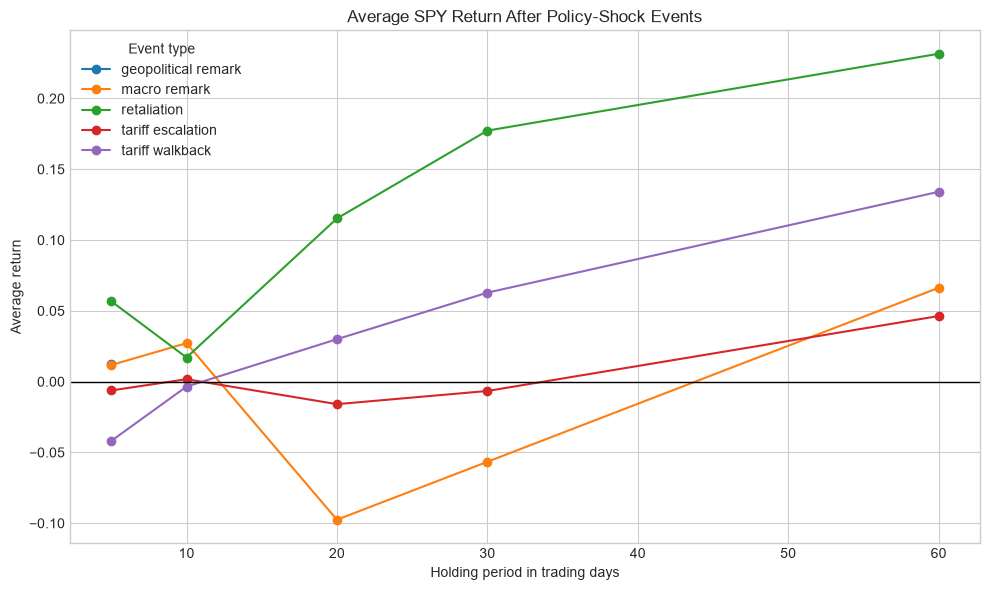

In [41]:
plot_data = event_type_summary.T
plot_data.index = hold_periods

plot_data.plot(figsize=(10, 6), marker="o")
plt.axhline(0, color="black", linewidth=1)
plt.title("Average SPY Return After Policy-Shock Events")
plt.xlabel("Holding period in trading days")
plt.ylabel("Average return")
plt.legend(title="Event type")
plt.tight_layout()
plt.show()

## Results and Interpretation

The main result is that SPY's average return after the selected policy-shock events is generally positive across the holding windows. 

This is directionally consistent with a hold-the-dip idea: after policy-driven uncertainty, SPY often recovered over the next few weeks or months. The strongest results appear in the longer 30- and 60-trading-day windows, especially for event types like retaliation and tariff walkbacks.

I still would not treat this as proof of a trading edge. The sample is small, the events are hand-picked, and several holding windows overlap. SPY also has a positive long-run drift, so buying after almost any date can look good over longer horizons, especially during bull-market regimes.

One thing I noticed is that the initial event shocks do not always create a large immediate SPY drawdown. That makes sense for a few reasons. Some announcements were partially expected before the official date, some were offset by later walkbacks or clarifications, and SPY is a broad index, so company- or sector-specific shocks can get diluted. The market may also care more about implementation risk, Fed policy, earnings, or liquidity conditions than the headline itself.

These events show positive post-event returns and are consistent with the intuition behind buying policy-driven weakness, but they do not yet prove that the event calendar beats normal market drift. The next improvement would be to compare these event returns against random dates, pre-event returns, and buy-and-hold returns over the same holding periods.

(Coming next commit)

## Skills I Built From This Notebook

This project helped me improve my analysis skills, especially around financial time-series data and hypothesis testing.

- Practiced time-series data handling with `pd.to_datetime`, `pd.Timedelta`, `.rolling()`, `.pct_change()`, `.loc`, and `.iloc`.
- Got more comfortable using pandas tools like `merge`, `groupby`, `agg`, and `sort_values` to organize market data and summarize results.
- Learned how to turn a market idea into a testable hypothesis: define the event, choose holding periods, calculate forward returns, and compare the results across groups.
- Built more intuition for market behavior around drawdowns, policy shocks, tariff headlines, geopolitical selloffs, and event-driven volatility.
- Practiced documenting the methodology clearly enough that someone else could understand what was tested and why.
